# Programming Exercise 1 : Search Algorithms and Uninformed Search

In this notebook you are going to find code and exercises for the first part of your programming project. For this project, you are going to work on a path-finding game, dubbed as RoBoToMaZe, which we have created just for you! 

**What to submit?** Just this notebook, with your code and answers for the various tasks and questions.

## RoBoToMaZe Rules, Instructions and pygame Installation

RoBoToMaZe is a simple variant of a path finding game. Given a two-dimensional grid space (that is, space divided into cells), we have a cell that hosts our token (the robot, if you prefer), a cell that corresponds to the goal (where the robot has to go) and then cells that are obstacles and cells that are free. 

The robot is depicted as a yellow circle, the goal as a red cell, obstacles are in blue and all free cells, where the robot can move to, are in white.

The robot is allowed to move one cell up, down, right or left, assuming that no obstacle is in one of these positions. To move the robot, all you have to do is to click to the cell you want to move the robot to, but only within the robot's legal neighbourhood.

The goal is, to move the robot to the goal (red) cell. It is pretty easy and not an inspiring game, but it serves as a good canvas for designing, developing and testing search algorithms, like the ones we learn in our class.

In the window of the game, you can quit the game, or draw a new game, by clicking the corresponding buttons.

To play the game, you can simply run the next two cells. The first contains all the necessary libraries. The second, a simple implementation for the game. The game is implemented through a series of functions. Some of these functions support graphical parts of the game and others logical parts. The game is essentially run through the main function.

We assume you all have a working python installation on your system (please make sure you do and that you have python version 3.x). You should also install pygame. That is very easy, and can be done by simply executing: 
`pip install pygame`. 

If pip does not work for you, then please just try the method you normally use to install python packages. 

We recommend you have a python version 3.10 and above and a pygame version 2.5.2 and above. All the code and examples given for this course are written and tested with Python 3.12.3 and pygame 2.6.1.

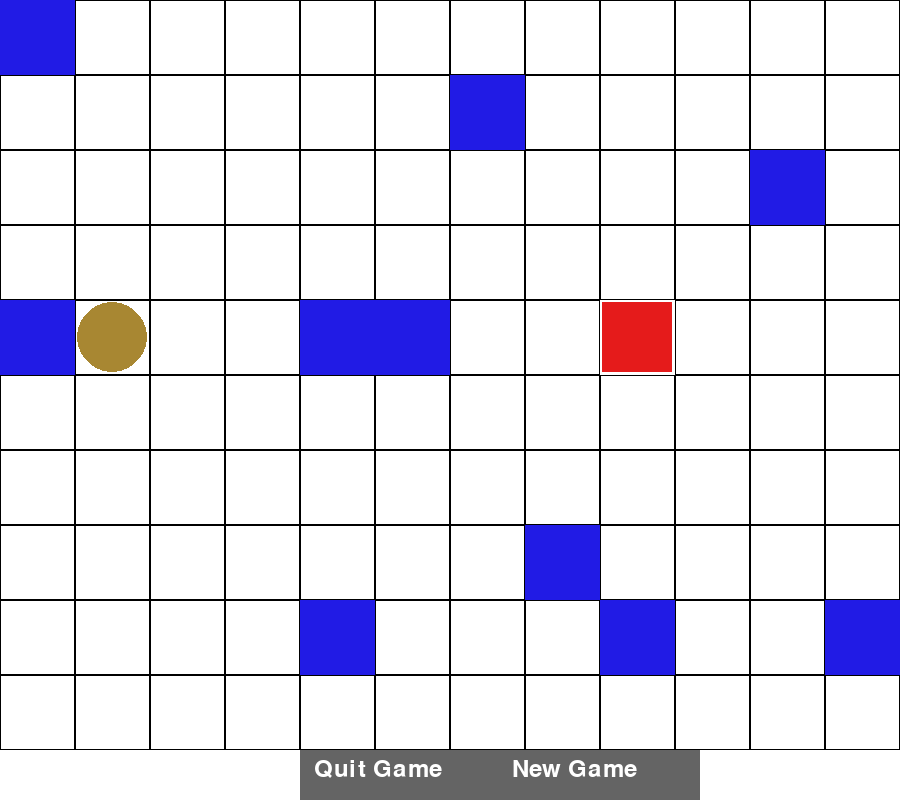

In [3]:
## In this cell, we import all the libraries we are going to use for this notebook
## I recommend you adopt this good-programming practise where all necessary
## libraries for your script are imported and found at the top of the script.
# Make sure you can run this cell with no issues.
# That means, your system should have and support all the necessary libraries.
# evan push to test pushing test 2

import pygame
from pygame.locals import *
import sys
import numpy as np
from numpy import random
import random
import time

pygame 2.6.1 (SDL 2.28.4, Python 3.10.19)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [ ]:
def make_game_basics(res, game_title):
    ''' Function for initializing a resolution for the game window, the game screen, display a name for the game and define colours that
    will be used throughout the graphical parts of the game. 
    Inputs:
    res: the resolution of the screen of the game
    game_title : how the game will be called - that will appear at the top of the game window
    Outputs:
    res : as before
    screen : a window pygame object where everything will be superimposed on while the game is running
    colors : the defined colours to be used throughout the game
    width : the width of the screen window (through the resolution variable)
    height : the height of the screen window (through the resolution variable)'''
    
    res = res 
    screen = pygame.display.set_mode(res) 
    
    pygame.display.set_caption(game_title)

    colors = {"white" :(255,255,255), "black" : (0,0,0), 
              "gray" :(100,100,100), "yellow" : (168, 135, 50), "red": (229, 27, 27),
              "blue" : (33, 27, 229), "pink": (242, 192, 227), "green": (0, 255, 0)}
    
    width = screen.get_width() 
    height = screen.get_height()  

    return res, screen, colors, width, height

def make_text(myfont, text, color):
    ''' Function for making text objects that will be displayed on the game screen.
    Inputs:
    myfont : the font object that defines the font type and size of the text to be displayed
    text : the string that will be displayed on the game screen
    color : the colour of the text to be displayed on the game screen
    Outputs:
    new_text : the text object that will be displayed on the game screen
    new_text_size : the size of the text object that will be displayed on the game screen'''
    new_text = myfont.render(text, True ,color)
    new_text_size = new_text.get_size()
    new_text_rect = new_text.get_rect()
    
    return new_text, new_text_size

def make_rect_with_text(surface, color, c1, c2, w, h, text, text_c1, text_c2):

    pygame.draw.rect(surface, color, [c1, c2, w, h])
    surface.blit(text, (text_c1, text_c2))

def gridCoords(cellSize):
    ''' Function for making a list of coordinates for the cells in the grid. 
    The coordinates are defined as the (x,y) of the top left corner of each cell.
    Inputs:
    cellSize : the size of the cells in the grid (the grid is made of squares, so the width and height of the cells are the same)
    Outputs:
    cells_coords : a list of coordinates for the cells in the grid. Each element of the list is a tuple of the form (x,y) where x and y are
    the coordinates of the top left corner of the cell.'''
    cells_coords = []
    for x in range(0, width, cellSize):
        for y in range(0, height-90, cellSize):
            cells_coords.append((x,y))

    return(cells_coords)
    
def drawGrid(surface, color, cells_coords, cellSize):
    ''' Function for drawing the grid on the game screen. The grid is made of squares, so we can use the
      pygame.Rect function to draw the cells of the grid.
      Inputs: surface : the game screen where the grid will be drawn
      color : the color of the grid lines
      cells_coords : the list of coordinates for the cells in the grid (the output of the gridCoords function)
      cellSize : the size of the cells in the grid (the output of the gridCoords function)
      Outputs: rects_coords : a list of tuples, where each tuple contains a 
      pygame.Rect object for the cell and the coordinates of the cell.'''
    rects_coords = []
    for item in cells_coords:
        rect = pygame.Rect(item[0], item[1], cellSize, cellSize)
        pygame.draw.rect(surface, color, rect, 1)
        rects_coords.append((rect, item))

    return(rects_coords)

def drawRobot(surface, color, coords, cellSize):
    ''' Function for drawing the robot on the game screen.
    Inputs:
    surface : the game screen where the robot will be drawn
    color : the color of the robot
    coords : the coordinates of the top left corner of the robot cell
    cellSize : the size of each cell in the grid
    Outputs:
    None (the function just draws the robot on the game screen)'''
    rect = pygame.Rect(coords[0], coords[1], cellSize, cellSize)
    pygame.draw.rect(surface, colors["black"], rect,1)
    
    pygame.draw.circle(surface, color, [coords[0]+(cellSize/2), coords[1]+(cellSize/2)], (cellSize/2)-2)

def drawGoal(surface, color, coords, cellSize):
    
    rect = pygame.Rect(coords[0]+2, coords[1]+2, cellSize-5, cellSize-5)
    pygame.draw.rect(surface,color, rect)

def drawObstacles(surface, color, coords, cellSize):

    for item in coords:
        
        rect = pygame.Rect(item[0], item[1], cellSize, cellSize)
        pygame.draw.rect(surface, color, rect)

def sample_cells(cells, number=1):
    ''' Function for sampling the initial position of the robot, the position of the goal and the positions of the obstacles.
    Inputs:
    cells : the list of coordinates for the cells in the grid (the output of the gridCoords function)
    number : the number of obstacles to be sampled (default is 1)
    Outputs:
    robot_cell : the coordinates of the top left corner of the cell where the robot will start
    goal_cell : the coordinates of the top left corner of the cell where the goal will be located
    obstacle_cells : a list of coordinates for the top left corner of the cells where the obstacles will be located
    '''
    robot_cell = (300, 300) # changed starting pos from (75, 300) -> (300, 300)
    goal_cell = (600,300)
    cells.remove(robot_cell)
    cells.remove(goal_cell)
    
    return robot_cell, goal_cell, random.sample(cells, number)

def legalMove(robot, clicked, rect_coords, obstacles, width, height, cellSize):
    ''' Function for checking if a move is legal.
    Inputs:
    robot : the current position of the robot (x,y coordinates)
    clicked : the position of the click (x,y coordinates)
    rect_coords : a list of tuples, where each tuple contains a pygame.Rect object for the cell and the coordinates of the cell
    obstacles : a list of coordinates for the top left corner of the cells where obstacles are located
    width : the width of the game screen
    height : the height of the game screen
    cellSize : the size of each cell in the grid
    Outputs:
    new_robot_x, new_robot_y : the new position of the robot (x,y coordinates)'''
    new_robot_x, new_robot_y = robot
    
    x,y = clicked
    
    # if the click is within the legal play area
    if 0 < x < width and 0 < y < height-90:
        
        #find the (x,y) of the cell that is clicked:
        x, y = clicked
        for i in range(len(rect_coords)):
            j = rect_coords[i]
            if j[0] <= x <= j[0]+cellSize and j[1] <= y <= j[1]+cellSize:
                cell_x,cell_y = j[0], j[1]
        
        # check if the cell is in the neighbourhood of the robot
        rX,rY = robot
        if (cell_x == rX+cellSize and cell_y == rY) or (cell_x ==rX-cellSize and cell_y == rY) or (cell_x == rX and cell_y ==rY+cellSize) or (cell_x == rX and cell_y == rY-cellSize):
            
            # check if the cell is an obstacle
            if (cell_x,cell_y) not in obstacles:
                
                new_robot_x, new_robot_y = cell_x, cell_y
                
            else:
                new_robot_x, new_robot_y = robot
    return new_robot_x, new_robot_y

def reachedGoal(path, clicked, goal, width, height, cellSize):
    
    flag = False
    x,y = clicked
    
    #check if the goal cell is clicked
    if goal[0]<= x <=goal[0]+cellSize and goal[1] <= y <= goal[1]+cellSize:
        
        #check if the robot had been in the neighbourhood in the previous step
        lastX, lastY = path[-2]
        if (lastX == goal[0]+cellSize and lastY == goal[1]) or (lastX ==goal[0]-cellSize and lastY == goal[1]) or (lastX == goal[0] and lastY ==goal[1]+cellSize) or (lastX == goal[0] and lastY == goal[1]-cellSize):

            flag = True    
                
    return flag

def get_valid_neighbours(current_cell, all_cells, cellSize, obstacles):
    # return the neighbours of the current position of the robot, which are not obstacles
    # even if one of the neighbours is the goal state, it should just be returned as a
    # normal neighbour in this function

    x,y = current_cell
    neighbours = []
    
    for item in all_cells:
        nX, nY = item[0], item[1]
        if (x == nX + cellSize and y == nY) or (x == nX - cellSize and y ==nY) or (x == nX and y == nY + cellSize) or (x == nX and y == nY - cellSize):
            if item not in obstacles:
                neighbours.append(item)

    return neighbours

def build_legal_moves(all_cells, cellSize, obstacles):
    legal_moves = {}
    for item in all_cells:
        legal_moves[item] = get_valid_neighbours(item, all_cells, cellSize, obstacles)
    return legal_moves

def bfs(starting_cell, goal_cell, legal_moves):

    queue = [starting_cell]
    visited = []

    while queue:
        current_cell = queue.pop(0)
        visited.append(current_cell)
        if current_cell == goal_cell:
            break
        for item in legal_moves[current_cell]:
            if item not in visited and item not in queue:
                queue.append(item)
    return visited

def dfs(starting_cell, goal_cell, legal_moves):

    stack = [starting_cell]
    visited = []

    while stack:
        current_cell = stack.pop()
        visited.append(current_cell)
        if current_cell == goal_cell:
            break
        for item in legal_moves[current_cell]:
            if item not in visited and item not in stack:
                stack.append(item)
    return visited





pygame.init()
pygame.font.init()
clock = pygame.time.Clock()
    
res, screen, colors, width, height = make_game_basics((900, 800), "Roboto-maze")

''' Here we define three different font sizes that we 
will use for the text that will be displayed on the game screen.'''
tinyfont = pygame.font.SysFont("Corbel",25)
smallfont = pygame.font.SysFont('Corbel',35) 
bigfont = pygame.font.SysFont("Corbel", 50)

quit_game, quit_game_size = make_text(bigfont, "Quit Game", colors["white"]) # adjust font size
new_game, new_game_size = make_text(bigfont, "New Game", colors["white"]) # adjust font size
win_game, win_game_size = make_text(smallfont, "Yay!", colors["blue"]) # adjusted win game message

quit_button_coords = [300, 750, 200, 50]
new_game_button_coords = [500, 750, 200, 50]

cellSize = 75

def main():

    flag = False
    click_robot = False
    grid_coords = gridCoords(cellSize)
    all_coords = grid_coords.copy()
    path = []
    robot_start, goal_cell, obstacle_cells = sample_cells(grid_coords, 20) # adjusted num of obstacles from 25 to 20
    path.append(robot_start)
    legal_moves = build_legal_moves(all_coords, cellSize, obstacle_cells)

    start = time.time()
    bfs_visited = bfs(robot_start, goal_cell, legal_moves)
    bfs_time = time.time() - start

    start = time.time()
    dfs_visited = dfs(robot_start, goal_cell, legal_moves)
    dfs_time = time.time() - start

    print("BFS visited:", bfs_visited)
    print("BFS states:", len(bfs_visited), ", Time:", bfs_time)

    print("DFS visited:", dfs_visited)
    print("DFS states:", len(dfs_visited), ", Time:", dfs_time)
    
    while True:
            
        screen.fill(colors["white"]) 
        mouse = pygame.mouse.get_pos() 

        drawGrid(screen, colors["black"], grid_coords, cellSize)
        drawRobot(screen, colors["yellow"], robot_start, cellSize)
        drawGoal(screen, colors["green"], goal_cell, cellSize) # changing color of the goal cell to green

        drawObstacles(screen, colors["blue"], obstacle_cells, cellSize)

        ''' Make the text with the buttons and the buttons themselves appear on the game screen. 
        The make_rect_with_text function takes care of both drawing the rectangle for the button and putting the text on top of it.
        Sets up the quit game and new game buttons on the game screen.'''
        make_rect_with_text(screen, colors["gray"], quit_button_coords[0], 
                        quit_button_coords[1], quit_button_coords[2], 
                        quit_button_coords[3], 
                        quit_game, quit_button_coords[0]+(quit_game_size[0]/2)-50, 
                       quit_button_coords[1] + (quit_game_size[1]/2)-5)
    
        make_rect_with_text(screen, colors["gray"], new_game_button_coords[0], 
                        new_game_button_coords[1], new_game_button_coords[2], 
                        new_game_button_coords[3], 
                        new_game, new_game_button_coords[0]+(new_game_size[0]/2)-50, 
                       new_game_button_coords[1] + (new_game_size[1]/2)-5)
        
                
        
        
        for ev in pygame.event.get():
            
            if ev.type == pygame.QUIT: 
                pygame.quit() 
                sys.exit()

            #checks if a mouse is clicked 
            ''' If the mouse is clicked, we check if the click is on one of the buttons. 
            If it is, we either quit the game or start a new game. Or if the click is not on the buttons, we check if the click is a legal move for the robot.
            '''
            if ev.type == pygame.MOUSEBUTTONDOWN: 
               
                if quit_button_coords[0] <= mouse[0] <= quit_button_coords[0]+200 and quit_button_coords[1] <= mouse[1] <= quit_button_coords[1]+50: 
                    pygame.quit() 
                    sys.exit()
    
                if new_game_button_coords[0] <= mouse[0] <= new_game_button_coords[0]+200 and new_game_button_coords[1] <= mouse[1] <= new_game_button_coords[1]+50:
                    main()

                robot_start = legalMove(robot_start, mouse, all_coords, obstacle_cells, width, height, cellSize)
                path.append(robot_start)
                
                if reachedGoal(path, mouse, goal_cell, width, height, cellSize):
                    
                    flag = True
        ''' If the flag is True, that means the goal has been reached, so we make the "Fantastic!" text appear on the game screen. The make_rect_with_text function
          takes care of both drawing the rectangle for the text and putting the text on top of it.'''
        if flag == True:
            make_rect_with_text(screen, colors["gray"], 150-win_game_size[0]/2, 120-win_game_size[1]/2, win_game_size[0], win_game_size[1]+60, 
                        win_game, 150-(win_game_size[0]/2), 
                       120 + (win_game_size[1]/2))

        pygame.display.update()
        clock.tick(60)
main()

BFS visited: [(300, 300), (300, 225), (300, 375), (375, 300), (300, 150), (375, 225), (225, 375), (375, 375), (450, 300), (225, 150), (300, 75), (375, 150), (450, 225), (150, 375), (225, 450), (450, 375), (525, 300), (150, 150), (225, 75), (300, 0), (375, 75), (450, 150), (525, 225), (75, 375), (150, 300), (150, 450), (225, 525), (450, 450), (525, 375), (600, 300)]
BFS states: 30 , Time: 5.5789947509765625e-05
DFS visited: [(300, 300), (375, 300), (450, 300), (525, 300), (600, 300)]
DFS states: 5 , Time: 5.9604644775390625e-06


SystemExit: 

/opt/anaconda3/envs/robomaze/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


: 

>**Task 1: (20/100 Points)**
>
> 1. [10 Points] Read through the given code, understand what is going on and add explanatory comments in all indicated functions and blocks of code. Your comments should provide a *brief yet concise and precise* explanation of the functionality of the function/block of code and, in the case of functions, what are the inputs and outputs. An example has been done for you for the function `make_game_basics`. You should finish all other indicated locations in the code with your own comments (there are 10 indicated locations in total, each is awarded with 1 Point). Notice, there are a few comments already in the code to help you orient yourselves.
> 2. [10 Points] Make 5 changes in the provided code in order to customize it (each change receives 2 Points). You need to change the following:
>    - The starting cell of the robot
>    - The number of obstacles used in the game
>    - The colour of the goal cell (by adding a new one and not by using one of the already existing in the code)
>    - The congratulatory message that appears when a player has reached the goal cell
>    - The font of the New Game and Quit Game buttons

## Building an AI to find the solution to the game

Now we need to make an agent that, if we wished, could play the game for us. We will start by considering the game as a search problem and a case where we wish to apply a search algorithm in order to find solutions. 

Your next task is to implement search algorithms that would help your AI explore the search space, explore the available moves and from that, find a path (sequence of moves) that will lead to the goal. 

> **Task 2 (25/100 Points):**
> 
> 1. [15 Points] Write a function **bfs()**, that implements the Breadth First search algorithm. Given a world where each cell is described by the coordinates of its top left corner, in two-dimensions (like in the RoBoToMaZe), the algorithm should receive as input the coordinates of the cells. Some of the coordinates would constitute the starting location of the robot, some the goal, others obstacles and free cells. Then, the function should explore the cells in the system to find a path from the starting cell to the goal cell, following legal moves and the BFS strategy. Your implementation should be such that, upon "generating" the goal cell, the algorithm stops exploring and returns the visited structure, a structure that contains the order in which the legal cells were visited by the algorithm. In order to implement the algorithm, you **should** use the code from notebook uninformed_search_exercises as inspiration and build on that. The grading will be based on the logic of the implementation. Does it use the right data structure? Does it do what it is meant to do, that is, does it visit the cells in the order intended by the algorithm? Does it return the requested and expected result?
> 2. [10 Points] Next step would be to test your function. Before using the RoBoToMaZe for this, we will apply a simpler test on simpler, and more importantly, smaller, two-dimensional worlds. In the cell below, you are given two such scenarios, each implemented using a different approach, both kept simple so that the code can be read through by all programming levels. Test your bfs() implemention using those scenarios and add two more scenarios of your own design. Remember to comment on what is special in your scenarios - that is, in what way do they try to challenge the algorithm, if at all. Your scenarios should consider a bigger world (more than 4x4) and obstacles! It is very important that, at this stage of your project, the bfs() implementation works as expected for all the test scenarios! The grading will be based on applying the test correctly, on providing two more scenarios and sufficiently commenting on your scenarios' designs.

In [17]:
def bfs(starting_cell, goal_cell, legal_moves):
    # timing
    start_time = time.time()
    
    # Write the function here - remember to add all necessary paremeters in the function declaration above
    queue = [starting_cell]
    visited = []

    while queue:
        current_cell = queue.pop(0)
        visited.append(current_cell)
        if current_cell == goal_cell:
            break
        for item in legal_moves[current_cell]:
            if item not in visited and item not in queue:
                queue.append(item)

    end_time = (time.time() - start_time) * 1000
    return visited, end_time

''' First test scenario : a 4x4 grid world'''
starting_cell = (3,0)
goal_cell = (1,3)


legal_moves = {
    (0,0) : [(0,1), (1,0)],
    (0,1) : [(0,0), (0,2), (1,1)],
    (0,2) : [(0,1), (0,3), (1,2)],
    (0,3) : [(0,2), (1,3)],
    (1,0) : [(0,0), (2,0), (1,1)],
    (1,1) : [(0,1), (1,0), (1,2), (2,1)],
    (1,2) : [(1,1), (0,2), (1,3), (2,2)],
    (1,3) : [(1,2), (0,3), (2,3)],
    (2,0) : [(1,0), (2,1), (3,0)],
    (2,1) : [(2,0), (1,1), (2,2), (3,1)],
    (2,2) : [(1,2), (2,1), (3,2), (2,3)],
    (2,3) : [(2,2), (1,3), (3,3)],
    (3,0) : [(2,0), (3,1)],
    (3,1) : [(3,0), (2,1), (3,2)],
    (3,2) : [(3,1), (2,2), (3,3)],
    (3,3) : [(3,2), (2,3)]
}

## Run your test for the first test scenario here

res_1, time_1 = dfs(starting_cell, goal_cell, legal_moves)
print("Test scenario one (basic grid test):", res_1)
print("Num. cells visited:", len(res_1))
print(f"Alotted time: {time_1:.3f} ms\n")

''' Second test scenario : a 4x4 grid world with obstacles'''

starting_cell = (3,0)
goal_cell = (1,3)
obstacles = [(1,1), (1,2), (3,1), (3,2)]

def generate_legal_moves(obstacles, dim):

    legal_moves = {}

    for i in range(dim):
        for j in range(dim):
            
            cur_cell = (i,j)
            all_neighbours = [(i-1,j), (i, j-1),(i+1, j), (i, j+1)]
            legal_neighbours = []
            for item in all_neighbours:
                if item not in obstacles and item[0] >= 0 and item[0]< dim and item[1] >= 0 and item[1] < dim:
                    legal_neighbours.append(item)

            legal_moves[cur_cell] = legal_neighbours

    return legal_moves

## Run your test for the second test scenario here

res_2, time_2 = bfs(starting_cell, goal_cell, generate_legal_moves(obstacles, 4))
print("Test scenario two (board with obstacles test):", res_2)
print("Num. cells visited:", len(res_2))
print(f"Alotted time: {time_2:.3f} ms\n")

''' Third test scenario : a 4x4 grid world with no feasible path '''

# In this scenario, the goal cell is surrounded by obstacles on all sides and is therefore
# completely unreachable from the starting cell.
#
# The purpose of this scenario is to test how the algorithm handles the edge case where no valid solution exists. Using BFS, the algorithm 
# should systematically explore all reachable cells starting from the starting position, expanding outward to nearby cells first. 
# Since the goal cannot be reached, the algorithm should eventually expand all reachable cells and terminate without generating the goal cell.

# Write your test scenario here
starting_cell = (3,0)
goal_cell = (1,3)

# Block the goal
obstacles = [(0,3), (1,2), (2,3)]

## Run your test for the third test scenario here

res_3, time_3 = bfs(starting_cell, goal_cell, generate_legal_moves(obstacles, 4))
print(" *  *  *  X\n", "*  *  X  G\n", "*  *  *  X\n", "S  *  *  *")
print("Test scenario three (unreachable goal test):", res_3)
print("Num. cells visited:", len(res_3))
print(f"Alotted time: {time_3:.3f} ms\n")

''' Fourth test scenario : a 5x5 grid world, checking for optimality'''

# This test scenario is designed with multiple possible paths from the starting cell to the goal in a larger 5x5 grid. Whereas previous tests
# observed whether the algorithm reacts to obstacles preventing the robot from taking the shortest route to the goal, this
# test challenges the robot to find the shortest path among several valid routes.
# 
# By creating a test with multiple valid routes of different lengths, we aim to determine whether our bfs implementation conducts a robust, level-by-level exploration
# of nodes to always return the optimal (shortest) path to the goal.

# Write your test scenario here
starting_cell = (4,0)
goal_cell = (0,4)

# Obstacles act as barriers that force some routes to be longer than others. The shortest valid path from starting
# to the goal cell is: (4,0) -> (3,0) -> (3,1) -> (3,2) -> (2,2) -> (1,2) -> (1,3) -> (1,4) -> (0,4), length 9.
# Longer alternative routes exist but BFS should always return the shortest one first
obstacles = [(0,1), (1,1), (1,3), (2,3), (3,1), (3,3)]

## Run your test for the fourth test scenario here
res_4, time_4 = bfs(starting_cell, goal_cell, generate_legal_moves(obstacles, 5))

print(" *  X  *  *  G\n", "*  X  *  X  *\n", "*  *  *  X  *\n", "*  X  *  X  *\n", "S  *  *  *  *")
print("Test scenario four (optimality test):", res_4)
print("Num. cells visited:", len(res_4))
print(f"Alotted time: {time_4:.3f} ms\n")

## Check if path is actually optimal
# The original bfs() only tracks which cells were visited and in what order, but it does not record how it got there. To verify optimality we need to reconstruct the 
# actual path taken from start to goal, which requires tracking each cell's parent. bfs_optimal() allows us to measure the true path length 
# rather than the size of the visited list.

# path = get_path(starting_cell, goal_cell, res_4, generate_legal_moves(obstacles, 5))
# print("Shortest path:", path)
# print("Shortest path length:", len(path))
# print("Optimal:", len(path) == 9)


Test scenario one (basic grid test): [(3, 0), (3, 1), (3, 2), (3, 3), (2, 3), (1, 3)]
Num. cells visited: 6
Alotted time: 0.007 ms

Test scenario two (board with obstacles test): [(3, 0), (2, 0), (1, 0), (2, 1), (0, 0), (2, 2), (0, 1), (2, 3), (0, 2), (1, 3)]
Num. cells visited: 10
Alotted time: 0.010 ms

 *  *  *  X
 *  *  X  G
 *  *  *  X
 S  *  *  *
Test scenario three (unreachable goal test): [(3, 0), (2, 0), (3, 1), (1, 0), (2, 1), (3, 2), (0, 0), (1, 1), (2, 2), (3, 3), (0, 1), (0, 2)]
Num. cells visited: 12
Alotted time: 0.016 ms

 *  X  *  *  G
 *  X  *  X  *
 *  *  *  X  *
 *  X  *  X  *
 S  *  *  *  *
Test scenario four (optimality test): [(4, 0), (3, 0), (4, 1), (2, 0), (4, 2), (1, 0), (2, 1), (3, 2), (4, 3), (0, 0), (2, 2), (4, 4), (1, 2), (3, 4), (0, 2), (2, 4), (0, 3), (1, 4), (0, 4)]
Num. cells visited: 19
Alotted time: 0.019 ms



> **Task 3 (15/100 Points):**
> 
> Using your code from Task 2 for the BFS algorithm as inspiration, write code for implementing the DFS (Depth First Search) algorithm. The function should return a structure containing the cells in the order they were visited by the algorithm.
>
> Afterwards, use the same test scenarios (all four) from Task 2 to test your DFS implementation.
> 
> Grading: 10 Points are awarded for the logic of the function's implementation. Does it use the right data structure? Does it do what it is meant to do? Does it return the right result? 5 Points are awarded for the tests.

In [16]:
import queue


def dfs(starting_cell, goal_cell, legal_moves):
    # timing
    start_time = time.time()

    # Write the function here - remember to add all necessary parameters in the function declaration above
    stack = [starting_cell]
    visited = []
    
    while stack:
        current_cell = stack.pop()
        visited.append(current_cell)
        if current_cell == goal_cell:
            break
        for item in legal_moves[current_cell]:
            if item not in visited and item not in stack:
                stack.append(item)
    
    end_time = (time.time() - start_time) * 1000
    return visited, end_time

    
# Run your tests for the dfs on the four test scenarios here
''' First test scenario : a 4x4 grid world'''
starting_cell = (3,0)
goal_cell = (1,3)


legal_moves = {
    (0,0) : [(0,1), (1,0)],
    (0,1) : [(0,0), (0,2), (1,1)],
    (0,2) : [(0,1), (0,3), (1,2)],
    (0,3) : [(0,2), (1,3)],
    (1,0) : [(0,0), (2,0), (1,1)],
    (1,1) : [(0,1), (1,0), (1,2), (2,1)],
    (1,2) : [(1,1), (0,2), (1,3), (2,2)],
    (1,3) : [(1,2), (0,3), (2,3)],
    (2,0) : [(1,0), (2,1), (3,0)],
    (2,1) : [(2,0), (1,1), (2,2), (3,1)],
    (2,2) : [(1,2), (2,1), (3,2), (2,3)],
    (2,3) : [(2,2), (1,3), (3,3)],
    (3,0) : [(2,0), (3,1)],
    (3,1) : [(3,0), (2,1), (3,2)],
    (3,2) : [(3,1), (2,2), (3,3)],
    (3,3) : [(3,2), (2,3)]
}

res_1, time_1 = dfs(starting_cell, goal_cell, legal_moves)
## Run your test for the first test scenario here
print("Test scenario one (basic grid test):", res_1)
print("Num. cells visited:", len(res_1))
print(f"Alotted time: {time_1:.3f} ms\n")

''' Second test scenario : a 4x4 grid world with obstacles'''

starting_cell = (3,0)
goal_cell = (1,3)
obstacles = [(1,1), (1,2), (3,1), (3,2)]

def generate_legal_moves(obstacles, dim):

    legal_moves = {}

    for i in range(dim):
        for j in range(dim):
            
            cur_cell = (i,j)
            all_neighbours = [(i-1,j), (i, j-1),(i+1, j), (i, j+1)]
            legal_neighbours = []
            for item in all_neighbours:
                if item not in obstacles and item[0] >= 0 and item[0]< dim and item[1] >= 0 and item[1] < dim:
                    legal_neighbours.append(item)

            legal_moves[cur_cell] = legal_neighbours

    return legal_moves

## Run your test for the second test scenario here
res_2, time_2 = dfs(starting_cell, goal_cell, generate_legal_moves(obstacles, 4))
print("Test scenario two (board with obstacles test):", res_2)
print("Num. cells visited:", len(res_2))
print(f"Alotted time: {time_2:.3f} ms\n")

''' Third test scenario : a 4x4 grid world with no feasible path '''

# In this scenario, the goal cell is surrounded by obstacles on all sides and is therefore
# completely unreachable from the starting cell.
#
# The purpose of this scenario is to test how the algorithm handles the edge case where no valid solution exists. Using BFS, the algorithm 
# should systematically explore all reachable cells starting from the starting position, expanding outward to nearby cells first. 
# Since the goal cannot be reached, the algorithm should eventually expand all reachable cells and terminate without generating the goal cell.

# Write your test scenario here
starting_cell = (3,0)
goal_cell = (1,3)

# Block the goal
obstacles = [(0,3), (1,2), (2,3)]

## Run your test for the third test scenario here
res_3, time_3 = dfs(starting_cell, goal_cell, generate_legal_moves(obstacles, 4))
print(" *  *  *  X\n", "*  *  X  G\n", "*  *  *  X\n", "S  *  *  *")
print("Test scenario three (unreachable goal test):", res_3)
print("Cells visited", len(res_3))
print(f"Alotted time: {time_3:.3f} ms\n")

''' Fourth test scenario : a 5x5 grid world, checking for optimality'''

# This test scenario is designed with multiple possible paths from the starting cell to the goal in a larger 5x5 grid. Whereas previous tests
# observed whether the algorithm reacts to obstacles preventing the robot from taking the shortest route to the goal, this
# test challenges the robot to find the shortest path among several valid routes.
# 
# By creating a test with multiple valid routes of different lengths, we aim to determine whether our bfs implementation conducts a robust, level-by-level exploration
# of nodes to always return the optimal (shortest) path to the goal.

# Write your test scenario here
starting_cell = (4,0)
goal_cell = (0,4)

# Obstacles act as barriers that force some routes to be longer than others. The shortest valid path from starting
# to the goal cell is: (4,0) -> (3,0) -> (3,1) -> (3,2) -> (2,2) -> (1,2) -> (1,3) -> (1,4) -> (0,4), length 9.
# Longer alternative routes exist but BFS should always return the shortest one first
obstacles = [(0,1), (1,1), (1,3), (2,3), (3,1), (3,3)]
print(" *  X  *  *  G\n", "*  X  *  X  *\n", "*  *  *  X  *\n", "*  X  *  X  *\n", "S  *  *  *  *")

## Run your test for the fourth test scenario here
res_4, time_4 = dfs(starting_cell, goal_cell, generate_legal_moves(obstacles, 5))

print("Test scenario four (optimality test):", res_4)
print("Cells visited:", len(res_4))
print(f"Alotted time: {time_4:.3f} ms\n")

## Check if path is actually optimal
# The original bfs() only tracks which cells were visited and in what order, but it does not record how it got there. To verify optimality we need to reconstruct the 
# actual path taken from start to goal, which requires tracking each cell's parent. bfs_optimal() allows us to measure the true path length 
# rather than the size of the visited list.

# def dfs_optimal(starting_cell, goal_cell, legal_moves):
#     queue = [starting_cell]
#     visited = []
#     parent = {starting_cell: None}

#     while queue:
#         current_cell = queue.pop()
#         visited.append(current_cell)
#         if current_cell == goal_cell:
#             break
#         for item in legal_moves[current_cell]:
#             if item not in visited and item not in queue:
#                 parent[item] = current_cell
#                 queue.append(item)

#     # Reconstruct path from goal back to start
#     path = []
#     cell = goal_cell
#     while cell is not None:
#         path.append(cell)
#         cell = parent[cell]
#     path.reverse()
#     return path

# path = get_path(starting_cell, goal_cell, res_4, generate_legal_moves(obstacles, 5))
# print("Shortest path:", path)
# print("Shortest path length:", len(path))
# print("Optimal:", len(path) == 9)


Test scenario one (basic grid test): [(3, 0), (3, 1), (3, 2), (3, 3), (2, 3), (1, 3)]
Num. cells visited: 6
Alotted time: 0.007 ms

Test scenario two (board with obstacles test): [(3, 0), (2, 0), (2, 1), (2, 2), (2, 3), (3, 3), (1, 3)]
Num. cells visited: 7
Alotted time: 0.006 ms

 *  *  *  X
 *  *  X  G
 *  *  *  X
 S  *  *  *
Test scenario three (unreachable goal test): [(3, 0), (3, 1), (3, 2), (3, 3), (2, 2), (2, 1), (1, 1), (1, 0), (0, 0), (0, 1), (0, 2), (2, 0)]
Cells visited 12
Alotted time: 0.012 ms

 *  X  *  *  G
 *  X  *  X  *
 *  *  *  X  *
 *  X  *  X  *
 S  *  *  *  *
Test scenario four (optimality test): [(4, 0), (4, 1), (4, 2), (4, 3), (4, 4), (3, 4), (2, 4), (1, 4), (0, 4)]
Cells visited: 9
Alotted time: 0.007 ms



> **Task 4 (20/Points)**:
>
> Compare the implementations of BFS and DFS and their performance on your test scenarios. For this, you need to answer the following questions:
>
> 1. [5 Points] How many states (i.e., cells) were generated by each algorithm and for each test scenario?
> 2. [5 Points] Explain the results of the previous question (Task 4.1). For that you should compare both algorithms **and** all scenarios.
> 3. [5 Points] How much time, in seconds, did each algorithm require to return the visited structure for each test scenario? (for this task, you might need to update your functions in tasks 2 and 3 in order to measure time).
> 4. [5 Points] Explain the results of the previous question (Task 4.3). 
>
> How to measure time. You can use the following structure in order to measure the time it takes for the execution of some block of code.
>
> `start_time = time.time()`
> 
> `block of code here`
>
> `end_time = time.time() - start_time`
>
> where `end_time` gives you the desired result.

In [ ]:
# Write your responses for Task 4 here


> **Task 5 (15/100 Points):**
>
> Your next task is to make whatever changes are necessary to your earlier implementations of the BFS algorithm (Task 2) and DFS algorithm (Task 3) so that they can work for the RoBoToMaZe. That is, the updated functions need to be able to receive as input the coordinates of the cells, which of them are obstacles, which are free, where does the robot start from and where does it need to go, and use the corresponding search algorithm's logic to explore the grid in order to find a path from the starting location to the goal cell.
>
> All depending on how you implemented your search algorithms during tasks 2 and 3, you might not need to make any changes, and perhaps your code is ready to be plugged in. Most likely, however, you need to make some small changes in order to take into consideration the RoBoToMaZe setup. In that case, the updated versions should be given in the cell below. Either way, the functions have to return a structure `visited` that contains the cells of the grid in the order they were visited by each algorithm.
>
> Call both functions from inside the main function of the game. It should be possible that, upon opening the game, first the BFS implementation and then the DFS implementation run and the user is given (in a printed message) the order in which either algorithm visits the cells.
>
> Compare the two algorithms in terms of (a) the number of states generated by each of them and (b) the time it took to run.
> 
> Grading: 5 Points are awarded for giving functions that can work with the game. 5 Points are awarded for running the functions inside the main and at the right location. Another 5 Points are awarded for correctly comparing the two algorithms runs inside the game in terms of states generated and running time.

In [ ]:
# The updated versions of the algorithms, for Task 5, as well as the comparison details, should be given here

def build_legal_moves(all_cells, cellSize, obstacles):
    legal_moves = {}
    for item in all_cells:
        legal_moves[item] = get_valid_neighbours(item, all_cells, cellSize, obstacles)
    return legal_moves

def bfs(starting_cell, goal_cell, legal_moves):

    queue = [starting_cell]
    visited = []

    while queue:
        current_cell = queue.pop(0)
        visited.append(current_cell)
        if current_cell == goal_cell:
            break
        for item in legal_moves[current_cell]:
            if item not in visited and item not in queue:
                queue.append(item)
    return visited

def dfs(starting_cell, goal_cell, legal_moves):

    stack = [starting_cell]
    visited = []

    while stack:
        current_cell = stack.pop()
        visited.append(current_cell)
        if current_cell == goal_cell:
            break
        for item in legal_moves[current_cell]:
            if item not in visited and item not in stack:
                stack.append(item)
    return visited

> **Task 6 (5 Points)** : In a concise yet precise and detailed manner, describe how would you implement a function that, given the visited structure containing the cells in the order they were visited by the search algorithm (BFS or DFS) from the starting cell to the goal cell, one could use that to get the solution path.

In [ ]:
# Write your response to Task 6 here
'''
In order to implement a function that retrieves the solution path after running a search algorithm, we would store a parent cell reference for each node that is added
to the visited structure through a hashmap. Initially, the starting cell's parent reference is set to null (or None). For each subsequent exploration of a neighboring 
cell, the currently  visited cell is stored as that neighbor's parent if it is a legal move. Once the goal cell is reached, the solution path can be reconstructed by 
backtracking  from the goal cell to the start cell using the parent references---look up the parent cell of the current cell and add each cell to a list until we reach 
the starting cell. Then, we would have to reverse the list to produce the solution path since we are backtracking and collecting cells from the goal to the initial cell. 
'''

> **BONUS Task (15 Points)** : Give the function **get_path** that implements your logic from Task 6 - that is, given RoBoToMaZe world and the visited structure returned by your BFS() implementation, the **get_path** function should return the solution to follow in order to get from the starting cell to the goal one.
>
> Responding to this Task is ***OPTIONAL***. A correct implementation can receive max 15 Points, in case you have lost them in other Tasks. If you choose to respond to the Bonus Task and your implementation is not correct, you earn nothing and you lose nothing. 

In [ ]:
# Your code for BONUS Task (OPTIONAL) should go here
def get_path(starting_cell, goal_cell, visited, legal_moves):
    if goal_cell not in visited:
        return []
    
    parent = {}
    parent[starting_cell] = None

    for i in range(len(visited)):
        if i == 0:
            continue
        
        cur = visited[i]

        for j in range(i):
            prev = visited[j]
            if cur in legal_moves[prev]:
                parent[cur] = prev
                break
    
    path = []
    # start backtracking from the goal_cell
    cur_backtrack = goal_cell
    
    while cur_backtrack is not None:
        path.append(cur_backtrack)
        cur_backtrack = parent.get(cur_backtrack)
    
    path.reverse()
    return path